In [1]:

!pip install torch torchvision pandas numpy matplotlib seaborn scikit-learn pillow tqdm


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Training will use CPU.")

Device: cpu
GPU not available. Training will use CPU.


In [4]:
DATASET_PATH = r"D:\Bangladeshi Counterfeit Currency Image Dataset"

print("Dataset Path:", DATASET_PATH)

Dataset Path: D:\Bangladeshi Counterfeit Currency Image Dataset


In [5]:
print("Dataset folders:")

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    
    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)), "files")

Dataset folders:
Denomination-wise Distribution : 4 files


In [6]:
class_names = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Classes:", class_names)

Classes: ['Denomination-wise Distribution']


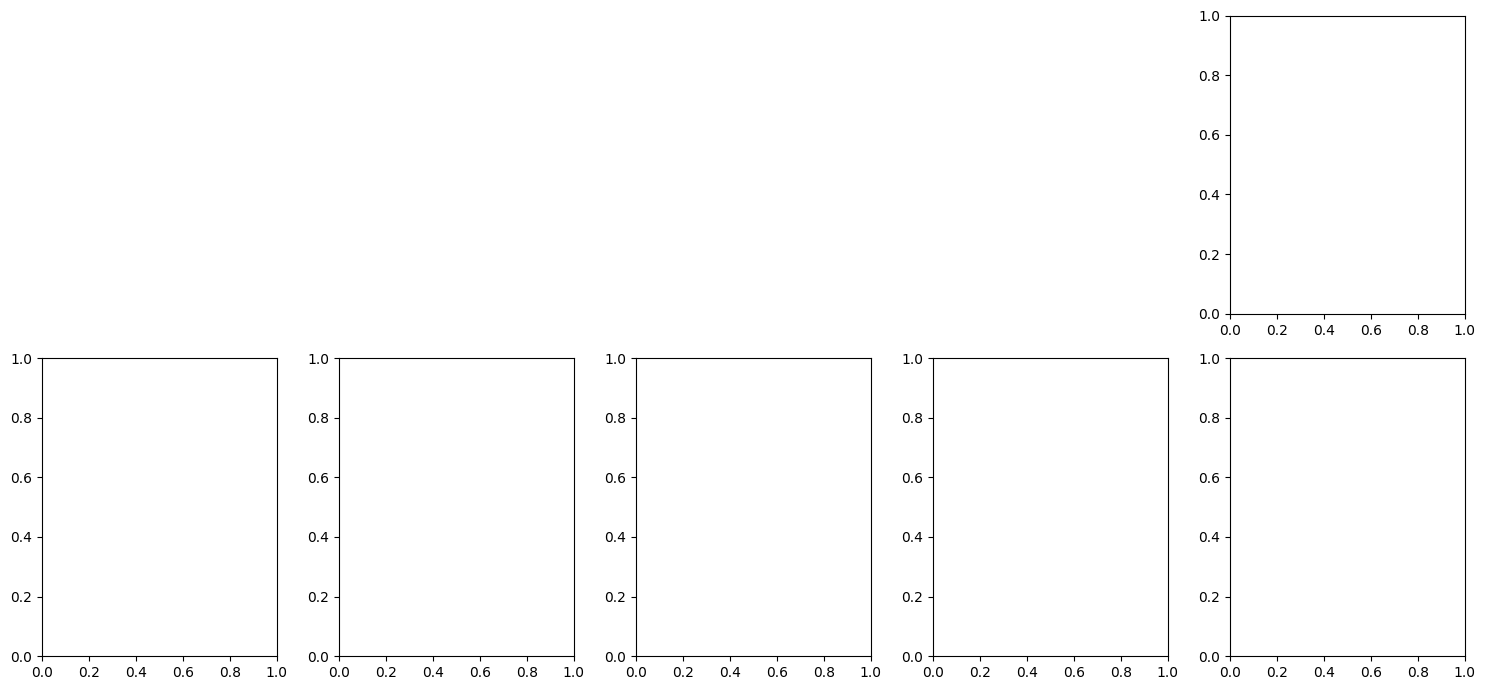

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for class_index, class_name in enumerate(class_names):
    
    class_path = os.path.join(DATASET_PATH, class_name)
    images = os.listdir(class_path)[:5]
    
    for i, image_name in enumerate(images):
        
        image_path = os.path.join(class_path, image_name)
        
        try:
            image = Image.open(image_path).convert("RGB")
            
            axes[class_index, i].imshow(image)
            axes[class_index, i].set_title(class_name)
            axes[class_index, i].axis("off")
            
        except:
            axes[class_index, i].axis("off")

plt.tight_layout()
plt.show()

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
from torch.utils.data import random_split

full_dataset = datasets.ImageFolder(
    DATASET_PATH,
    transform=train_transform
)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class mapping:", full_dataset.class_to_idx)

Total images: 1286
Classes: ['Denomination-wise Distribution']
Class mapping: {'Denomination-wise Distribution': 0}


In [10]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 1028
Validation images: 258


In [11]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoader created successfully!")

DataLoader created successfully!


In [12]:
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [13]:
num_classes = len(class_names)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)


In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(loader, desc="Training")
    
    for images, labels in progress_bar:
        
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        accuracy = 100 * correct / total
        
        progress_bar.set_postfix(
            loss=loss.item(),
            accuracy=f"{accuracy:.2f}%"
        )
    
    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total
    
    return epoch_loss, epoch_accuracy

In [16]:
def validate(model, loader, criterion, device):
    
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        
        for images, labels in loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total
    
    return epoch_loss, epoch_accuracy

In [17]:
EPOCHS = 3

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(EPOCHS):
    
    print("\n" + "=" * 50)
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("=" * 50)
    
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    
    print(f"\nTrain Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy * 100:.2f}%")
    
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
    
    # Save best model
    if val_accuracy > best_val_accuracy:
        
        best_val_accuracy = val_accuracy
        
        torch.save(
            model.state_dict(),
            "best_efficientnet_b0_currency.pth"
        )
        
        print("Best model saved!")


Epoch 1/3


Training: 100%|██████████| 33/33 [03:57<00:00,  7.20s/it, accuracy=100.00%, loss=0]



Train Loss: 0.0000
Train Accuracy: 100.00%
Validation Loss: 0.0000
Validation Accuracy: 100.00%
Best model saved!

Epoch 2/3


Training: 100%|██████████| 33/33 [03:43<00:00,  6.78s/it, accuracy=100.00%, loss=0]



Train Loss: 0.0000
Train Accuracy: 100.00%
Validation Loss: 0.0000
Validation Accuracy: 100.00%

Epoch 3/3


Training: 100%|██████████| 33/33 [03:45<00:00,  6.82s/it, accuracy=100.00%, loss=0]



Train Loss: 0.0000
Train Accuracy: 100.00%
Validation Loss: 0.0000
Validation Accuracy: 100.00%


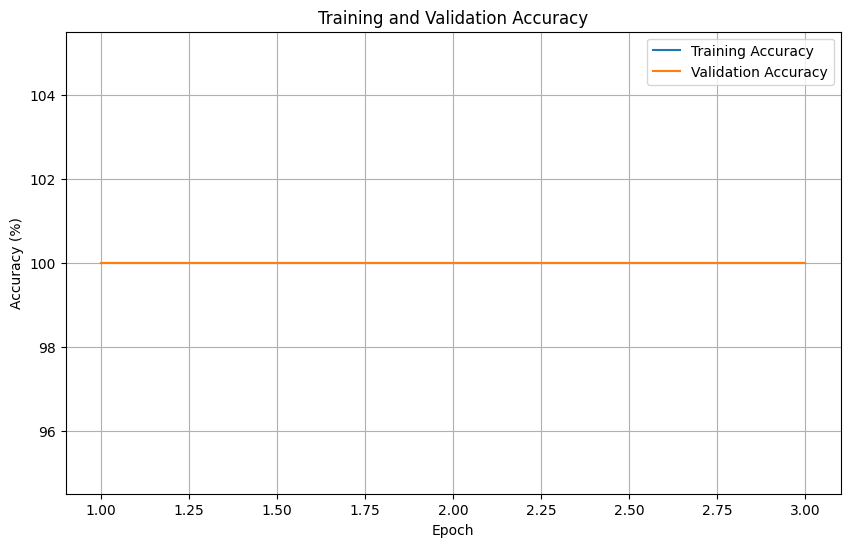

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, EPOCHS + 1),
    [x * 100 for x in train_accuracies],
    label="Training Accuracy"
)

plt.plot(
    range(1, EPOCHS + 1),
    [x * 100 for x in val_accuracies],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
model.load_state_dict(
    torch.load(
        "best_efficientnet_b0_currency.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [20]:
all_labels = []
all_predictions = []

with torch.no_grad():
    
    for images, labels in tqdm(val_loader, desc="Testing"):
        
        images = images.to(device)
        
        outputs = model(images)
        
        _, predictions = torch.max(outputs, 1)
        
        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

Testing: 100%|██████████| 9/9 [00:34<00:00,  3.88s/it]


In [21]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1 Score  : 100.00%


In [22]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        zero_division=0
    )
)

                                precision    recall  f1-score   support

Denomination-wise Distribution       1.00      1.00      1.00       258

                      accuracy                           1.00       258
                     macro avg       1.00      1.00      1.00       258
                  weighted avg       1.00      1.00      1.00       258



D:\Download\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


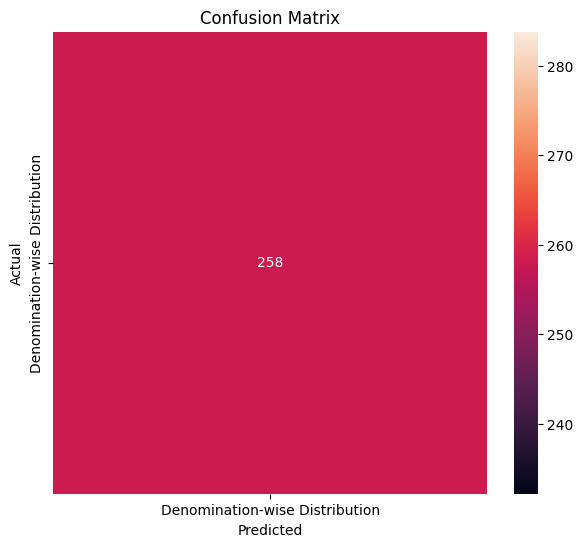

In [23]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

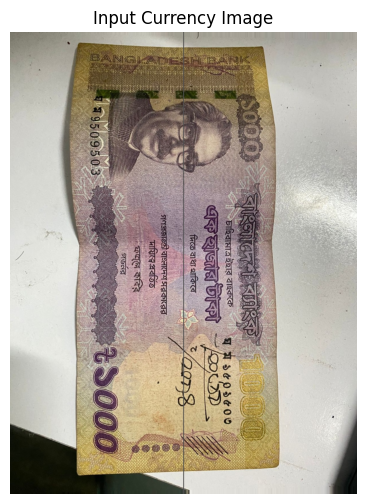

In [24]:
IMAGE_PATH = r"C:\Users\user\OneDrive\Desktop\Jupyter notebook\dataset\folded_1.jpg"
image = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Currency Image")
plt.show()

In [25]:
image_tensor = test_transform(image)

image_tensor = image_tensor.unsqueeze(0)

image_tensor = image_tensor.to(device)

model.eval()

with torch.no_grad():
    
    output = model(image_tensor)
    
    probabilities = torch.softmax(output, dim=1)
    
    confidence, predicted_class = torch.max(
        probabilities,
        dim=1
    )

predicted_label = class_names[predicted_class.item()]

confidence_value = confidence.item() * 100

print("Prediction:", predicted_label)
print(f"Confidence: {confidence_value:.2f}%")

Prediction: Denomination-wise Distribution
Confidence: 100.00%


In [28]:
print("Class Names:", class_names)
print("Class Mapping:", full_dataset.class_to_idx)

Class Names: ['Denomination-wise Distribution']
Class Mapping: {'Denomination-wise Distribution': 0}


In [29]:
print(full_dataset.classes)

['Denomination-wise Distribution']


In [27]:


torch.save(
    model.state_dict(),
    "EfficientNetB0_Fake_Currency_Detection.pth"
)

print("Model saved successfully!")

Model saved successfully!
